In [1]:
import cafe

# cafe.logger.setLevel("INFO")
cafe.logger.setLevel("DEBUG")

# cafe.settings.backend = "python_function"
cafe.settings.backend = "conda"
# cafe.settings.backend = "cfe_docker"

cafe.settings.save_external_data = True # save external data
cafe.settings.save_h5ad = True # save external data

INFO                                                                                                                                                                                                    
           ██████╗ █████╗ ███████╗███████╗                                                                                                                                                              
          ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                              
          ██║     ███████║█████╗  █████╗                                                                                                                                                                
          ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                            

DEBUG    |- Reading data from '/root/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad'...                                                                                                         
DEBUG    |- transfer 'X' and 'Spliced' matrix from csr to csc for better dynverse docker performance                                                                                                    
DEBUG    |- Create a FateAnnData object from an existing AnnData object.                                                                                                                                
DEBUG    |- recognizing prior information...                                                                                                                                                            
DEBUG    |--- recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                               

array([[<Axes: title={'center': 'ref(clusters)'}, xlabel='X_umap1', ylabel='X_umap2'>]],
      dtype=object)

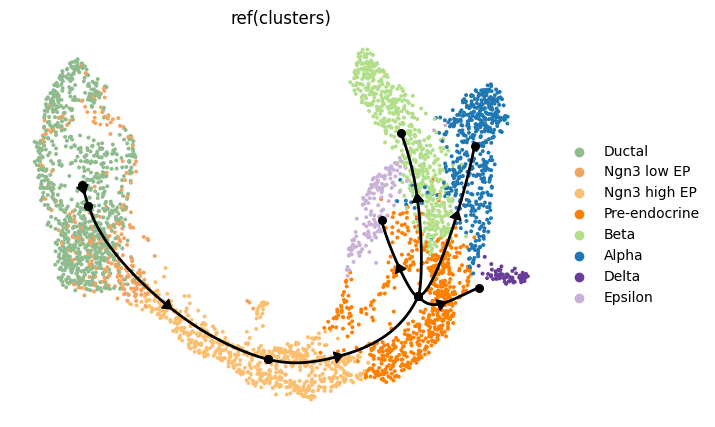

In [2]:
fadata = cafe.data.read_pancrease()
del fadata.uns["neighbors"] # velocity neighbor info error, need recalculate
cafe.plot.plot_trajectory(fadata)

In [3]:
method2parameters = {
    # "comp1": {
    #     "basis": "X_umap",
    #     "recompute_basis": False,
    # },
    # "state_comp": {
    #     "basis": "X_pca",
    #     "n_comps": 3,
    #     "recompute_basis": False,
    # },
    # "cluster_mst": {
    #     "basis": "X_umap",
    #     "recluster": False,
    # },
    # "projection_mst": {
    #     "basis": "X_umap", # project to umap
    #     "recluster": False,
    # },
    "graph_mst": {}, # TODO: too slow, becase too many nodes, need to optimize simplified algorithm for milestone network.
}

for method_name, parameters in method2parameters.items():
    parameters["repreprocess"] = True
    # parameters["benchmark_resource"] = True  # record resource usage
    method = cafe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata, parameters=parameters, id=method_name)
    # save in time, without waiting for all methods to finish, waypoint are not calculated
    fadata.write_trajectory_dict(model_name_list=[fadata.model_name])
    # cafe.plot.plot_trajectory(fadata, save=True)

DEBUG    |- load conda backend                                                                                                                                                                          
DEBUG    |--- Conda environment 'cfe' is available: Python 3.10.15                                                                                                                                      
DEBUG    |- Loaded function 'graph_mst': <function graph_mst at 0x7568d70c0700>                                                                                                                         
INFO     |- method backend loaded: CondaBackend: graph_mst in conda env 'cfe'                                                                                                                           
DEBUG    |- set new log file: .cafe/pancreas/log/graph_mst.log                                                                                                                                      

DEBUG    |- extract 'clusters' from prior infomation as parameter 'color'                                                                                                                               
DEBUG    |- extract 'X_umap' from prior infomation as parameter 'basis'                                                                                                                                 
DEBUG    |- calculate new trajectory embedding for model_name:graph_mst, basis:X_umap.                                                                                                                  
DEBUG    |- add waypoints                                                                                                                                                                               
DEBUG    |- FateAnnData add_waypoints                                                                                                                                                               

array([[<Axes: title={'center': 'graph_mst(clusters)'}, xlabel='X_umap1', ylabel='X_umap2'>]],
      dtype=object)

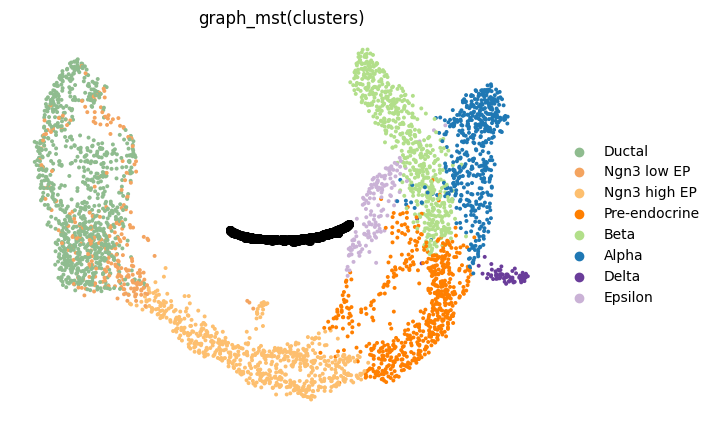

In [4]:
cafe.plot.plot_trajectory(fadata)

In [5]:
# model_name_list = fadata.get_all_model_name(parse=False)
# color_list = ["clusters", "milestone"]

# cafe.plot.plot_trajectory(fadata, model_name=model_name_list, color=color_list)

In [6]:
fadata.write_trajectory_dict() 

DEBUG    |- write trajectory 'ref' to '.cafe/pancreas/trajectory_history/ref.pkl'                                                                                                                       
DEBUG    |- write trajectory 'graph_mst' to '.cafe/pancreas/trajectory_history/graph_mst.pkl'                                                                                                           
